# Week 6, Phase 1 — corrected melt-pool monitor data audit

## 1. Scope

This notebook reports the rebuilt, pagination-safe audit of
`ioandanielc/sph_dataset` at immutable revision
`0e859b748fdbc8454f66e58e101e333ac0479d42`.

The reproducible build is implemented in
`src/week6_phase1_melt_pool_data_audit.py`. It enumerates the
repository before any scientific parsing, audits all simulation
folders, and produces one response row per actual folder. This
notebook reads those generated artifacts and checks their central
claims. It does not perform GP modelling or any Phase 2 work.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path.cwd().resolve()
OUT = ROOT / "outputs" / "week6_01_melt_pool_data_audit"
assert (ROOT / "src" / "week6_phase1_melt_pool_data_audit.py").exists()
assert OUT.exists()

summary = json.loads((OUT / "summary.json").read_text(encoding="utf-8"))
pd.Series({
    "chosen_revision": summary["chosen_revision"],
    "actual_simulation_folders": summary["actual_simulation_folder_count"],
    "numeric_id_range": (
        f"{summary['minimum_numeric_simulation_id']}–"
        f"{summary['maximum_numeric_simulation_id']}"
    ),
    "numeric_id_gaps": summary["numeric_id_gaps"],
    "dataset_shape": summary["final_dataset_shape"],
})

chosen_revision              0e859b748fdbc8454f66e58e101e333ac0479d42
actual_simulation_folders                                         241
numeric_id_range                                                1–242
numeric_id_gaps                                                 [136]
dataset_shape                                              [241, 199]
dtype: object

## 2. Immutable source and population controls

The audit is pinned to one immutable revision. The complete
population contains 241 folders spanning numeric IDs 1–242, with
only ID 136 absent; therefore row count must not be inferred from
the largest contiguous prefix.

In [2]:
pd.Series({
    "retired_method": "HfApi.repo_info(...).siblings",
    "single_payload_file_paths": (
        summary["enumeration"]["faulty_sibling_file_count"]
    ),
    "lexicographically_last_path": (
        summary["enumeration"]["faulty_last_path"]
    ),
    "corrected_primary_method": (
        summary["enumeration"]["primary_method"]
    ),
    "independent_http_pages_consumed": (
        summary["enumeration"]["independent_http_pages"]
    ),
})

retired_method                                         HfApi.repo_info(...).siblings
single_payload_file_paths                                                      98552
lexicographically_last_path        final_data_processed/sim_00117/frames/side/fra...
corrected_primary_method           HfApi.list_repo_tree(path_in_repo='final_data_...
independent_http_pages_consumed                                                    5
dtype: object

## 3. Why the previous listing failed

The retired result came from treating a single incomplete global
`repo_info().siblings` payload as a complete directory listing.
Direct path probes prove that later folders exist at the same SHA.

## 4. Pagination-safe enumeration

In [3]:
tree = pd.read_csv(OUT / "repository_tree_audit.csv")
direct = pd.read_csv(OUT / "revision_path_existence_checks.csv")
display(tree)
display(
    direct.pivot(
        index="simulation_id",
        columns="revision_label",
        values="exists",
    )
)

,method,revision,enumeration_scope,pages_or_batches_consumed,items_or_files_observed,simulation_folder_count,minimum_numeric_id,maximum_numeric_id,sim_00242_observed,complete,evidence
0,previous_faulty_global_sibling_payload,0e859b748fdbc8454f66e58e101e333ac0479d42,global repository metadata,1,98552,NaN,1,117,False,False,single siblings payload ended at final_data_pr...
1,primary_hfapi_immediate_directory_enumeration,0e859b748fdbc8454f66e58e101e333ac0479d42,final_data_processed immediate children,iterator consumed to exhaustion,244,241.0,1,242,True,True,HfApi.list_repo_tree(path_in_repo='final_data_...
2,independent_http_immediate_directory_enumeration,0e859b748fdbc8454f66e58e101e333ac0479d42,final_data_processed immediate children,5,244,241.0,1,242,True,True,HTTP tree API with explicit limit=50 and every...
3,per_simulation_recursive_mixed_enumeration,0e859b748fdbc8454f66e58e101e333ac0479d42,each discovered simulation folder,318 explicit HTTP pages; 12 fully consumed HfA...,207024,241.0,1,242,True,True,"205,819 files and 1,205 nested folders; `final..."


revision_label,chosen_revision,current_main,old_pinned_revision
simulation_id,,,
sim_00001,True,True,True
sim_00117,True,True,True
sim_00118,True,True,True
sim_00224,True,True,True
sim_00241,True,True,True
sim_00242,True,True,True


The primary directory-aware iterator and the independent
explicitly paginated HTTP enumeration both reach `sim_00242` and
agree on all 241 folders. Direct path probes also confirm the six
boundary/control simulations at the old revision, chosen revision,
and current `main` SHA.

## 5. Master reconciliation and folder inventory

In [4]:
folders = pd.read_csv(OUT / "simulation_folder_inventory.csv")
reconciliation = pd.read_csv(
    OUT / "experiments_folder_reconciliation.csv"
)
gaps = pd.read_csv(OUT / "numeric_simulation_id_gaps.csv")

display(reconciliation["membership_class"].value_counts())
display(gaps)
display(folders.iloc[[0, 116, 117, -2, -1]][[
    "simulation_id",
    "numeric_simulation_id",
    "recursive_pages_consumed",
    "recursive_item_count",
    "file_count",
]])

membership_class
both    241
Name: count, dtype: int64

,missing_numeric_id,expected_simulation_id,present_in_experiments_csv,present_in_folder_tree,interpretation
0,136,sim_00136,False,False,"numeric naming gap, not a silently dropped sim..."


,simulation_id,numeric_simulation_id,recursive_pages_consumed,recursive_item_count,file_count
0,sim_00001,1,2,1100,1095
116,sim_00117,117,2,1271,1266
117,sim_00118,118,1,425,420
239,sim_00241,241,2,1088,1083
240,sim_00242,242,2,1217,1212


`experiments.csv` and the repository tree match exactly: there are
no master-only or folder-only simulations and no duplicate IDs.
The boundary rows demonstrate that enumeration continues past
`sim_00117` through `sim_00242`.

## 6. File completeness, monitor types, and schemas

In [5]:
sim_files = pd.read_csv(OUT / "simulation_file_inventory.csv")
missing = pd.read_csv(OUT / "missing_file_report.csv")
dat_types = pd.read_csv(OUT / "dat_file_type_inventory.csv")

pd.Series({
    "simulations": len(sim_files),
    "all_have_34_monitor_dat_files": bool(
        sim_files["monitor_dat_count"].eq(34).all()
    ),
    "all_have_required_metadata": bool(
        sim_files[
            [
                "experiment_details_available",
                "parameters_available",
                "metadata_available",
                "labeling_provenance_available",
                "frames_csv_available",
                "monitor_available",
            ]
        ].all(axis=1).all()
        and sim_files["complete_for_phase1"].all()
    ),
    "missing_report_rows": len(missing),
    "monitor_file_types": len(dat_types),
})

simulations                       241
all_have_34_monitor_dat_files    True
all_have_required_metadata       True
missing_report_rows                 0
monitor_file_types                 34
dtype: object

Every folder has the required metadata, provenance, frame index,
time/iteration streams, melt bounds, and all 34 monitor `.dat`
types. The missing-file report is empty.

In [6]:
schemas = pd.read_csv(OUT / "monitor_schema_audit.csv")
dictionary = pd.read_csv(OUT / "monitor_data_dictionary.csv")

display(
    schemas.groupby("file_name").agg(
        sampled_simulations=("simulation_id", "nunique"),
        distinct_column_counts=("column_count", "nunique"),
        schema_consistency=(
            "schema_consistent_across_audited_simulations",
            "all",
        ),
    ).head(12)
)
display(dictionary.head(12))

,sampled_simulations,distinct_column_counts,schema_consistency
file_name,,,
average-temperature_gas.dat,13,1,True
average-temperature_melt.dat,13,1,True
average-temperature_substrate.dat,13,1,True
dt.dat,13,1,True
iter.dat,13,1,True
kinetic-energy_gas.dat,13,1,True
kinetic-energy_melt.dat,13,1,True
maximum-temperature_gas.dat,13,1,True
maximum-temperature_melt.dat,13,1,True


,file_name,column_index,column_name,inferred_meaning,unit,evidence,confidence_level,caveat
0,average-temperature_gas.dat,0,average_temperature_gas,average temperature_gas,K,file name and SI simulation configuration,medium,Headerless; unit is inferred from SI context u...
1,average-temperature_melt.dat,0,average_temperature_melt,average temperature_melt,K,file name and SI simulation configuration,medium,Headerless; unit is inferred from SI context u...
2,average-temperature_substrate.dat,0,average_temperature_substrate,average temperature_substrate,K,file name and SI simulation configuration,medium,Headerless; unit is inferred from SI context u...
3,dt.dat,0,dt,dt,s,sim_control time values and column behavior,high,Headerless; unit is inferred from SI context u...
4,iter.dat,0,iter,solver iteration index,iteration,strict integer sequence,high,Headerless; unit is inferred from SI context u...
5,kinetic-energy_gas.dat,0,kinetic_energy_gas,kinetic energy_gas,J,file name; SI solver context,medium,Headerless; unit is inferred from SI context u...
6,kinetic-energy_melt.dat,0,kinetic_energy_melt,kinetic energy_melt,J,file name; SI solver context,medium,Headerless; unit is inferred from SI context u...
7,maximum-temperature_gas.dat,0,maximum_temperature_gas,maximum temperature_gas,K,file name and SI simulation configuration,medium,Headerless; unit is inferred from SI context u...
8,maximum-temperature_melt.dat,0,maximum_temperature_melt,maximum temperature_melt,K,file name and SI simulation configuration,medium,Headerless; unit is inferred from SI context u...
9,maximum-temperature_substrate.dat,0,maximum_temperature_substrate,maximum temperature_substrate,K,file name and SI simulation configuration,medium,Headerless; unit is inferred from SI context u...


The broad 13-simulation schema sample covers early, boundary,
parameter-extreme, and late simulations. It parses all monitor
types consistently, while the data dictionary records units,
semantics, and the role of each stream.

## 7. Full-population bounds, time, and iteration parsing

In [7]:
bounds_manifest = pd.read_csv(OUT / "melt_bounds_manifest.csv")
pd.Series({
    "simulations_parsed": len(bounds_manifest),
    "total_bounds_rows": int(bounds_manifest["row_count"].sum()),
    "valid_melt_rows": int(bounds_manifest["valid_row_count"].sum()),
    "sentinel_rows": int(bounds_manifest["sentinel_row_count"].sum()),
    "all_stream_lengths_align": bool(
        bounds_manifest["row_alignment_passed"].all()
    ),
    "all_accepted_bounds_ordered": bool(
        bounds_manifest["ordered_bounds_passed"].all()
    ),
    "all_time_streams_monotonic": bool(
        bounds_manifest["time_monotonic_passed"].all()
    ),
    "all_iteration_streams_monotonic": bool(
        bounds_manifest["iteration_monotonic_passed"].all()
    ),
})

simulations_parsed                      241
total_bounds_rows                  25884257
valid_melt_rows                    21045355
sentinel_rows                       4838902
all_stream_lengths_align               True
all_accepted_bounds_ordered            True
all_time_streams_monotonic             True
all_iteration_streams_monotonic        True
dtype: object

All 241 melt-bounds streams parse and align exactly with their
`time.dat` and `iter.dat` streams. Sentinel rows are retained as
explicit missing-melt states, while accepted bounds obey min/max
ordering.

## 8. Physical-axis evidence

In [8]:
axis = pd.read_csv(OUT / "axis_evidence_summary.csv")
display(axis)

,coordinate,physical_interpretation,configuration_evidence,centre_motion_evidence,frame_evidence,confidence,caveat
0,X,positive laser scan direction; delta_x is melt...,"241/241 velocity vectors equal [VX,0,0]",median absolute centre displacement 773.8 µm,top (X-Y) and side (X-Z) views show the scan-a...,high — confirmed on complete population,"delta_x is a particle bounding extent, not a c..."
1,Y,transverse direction; delta_y is melt-pool width,241/241 velocity vectors have zero Y component,median absolute centre displacement 0.41 µm,front (Y-Z) view and top (X-Y) view show trans...,high — confirmed on complete population,width is a particle bounding extent
2,Z,vertical direction; z=0 is the original substr...,241/241 gravity and 241/241 beam vectors point...,median absolute centre displacement 22.6 µm,front (Y-Z) and side (X-Z) views show Z vertic...,high — confirmed on complete population,delta_z is total vertical span; penetration de...


Full-population configuration and trajectory evidence identify X
as the scan/length direction, Y as transverse/width, and Z as
vertical. Penetration below the original surface is therefore
`max(0, -z_min)`. The median center displacement is overwhelmingly
along X, reinforcing the metadata-based mapping.

## 9. Response and scalar-target selection

In [9]:
responses = pd.read_csv(OUT / "selected_response_summary.csv")
candidates = pd.read_csv(
    OUT / "scalar_target_candidate_comparison.csv"
)
display(responses)
display(
    candidates[
        [
            "response",
            "candidate",
            "available_simulation_count",
            "median_window_cv",
            "p90_window_cv",
            "selected_primary",
        ]
    ]
)

,response,dataset_prefix,source_and_formula,unit,valid_simulation_count,valid_percentage,target_min_um,target_median_um,target_max_um,median_selected_window_cv,p90_selected_window_cv,median_absolute_selected_window_trend,larger_smaller_interpretation,predictability_rationale,level_set_usefulness,selected_primary_scalar_definition,full_population_justification
0,Melt-pool width,melt_pool_width,position-bounds_melt.dat: y_max - y_min,m,241,100.0,86.30895,159.00522,256.76705,0.004894,0.015556,0.009240,Larger means a broader transverse molten region.,"P, VX, LS, and ST govern delivered energy dens...",Y-boundary scale across the scan track.,median over final 20% of melt-present time bef...,Retains every simulation and has lower variabi...
1,Melt-pool length,melt_pool_length,position-bounds_melt.dat: x_max - x_min,m,241,100.0,116.16170,341.37590,543.72645,0.013132,0.032207,0.035317,Larger means a longer scan-aligned molten region.,"P, VX, LS, and ST govern delivered energy dens...",X-boundary scale along the scan direction.,median over final 20% of melt-present time bef...,Retains every simulation and has lower variabi...
2,Penetration depth below original surface,melt_pool_depth_below_surface,"position-bounds_melt.dat: max(0,-z_min), confi...",m,241,100.0,15.10266,54.75336,122.20050,0.019639,0.062594,0.039260,Larger means deeper penetration into the subst...,"P, VX, LS, and ST govern delivered energy dens...",Vertical boundary scale with direct physical i...,median over final 20% of melt-present time bef...,Retains every simulation and has lower variabi...


,response,candidate,available_simulation_count,median_window_cv,p90_window_cv,selected_primary
0,melt_pool_depth_below_surface,final_recorded,171,NaN,NaN,False
1,melt_pool_depth_below_surface,last_valid_melt_present,241,NaN,NaN,False
2,melt_pool_depth_below_surface,maximum,241,NaN,NaN,False
3,melt_pool_depth_below_surface,full_melt_present_median,241,0.335215,0.559972,False
4,melt_pool_depth_below_surface,final_20pct_melt_present_median,241,0.082298,2.085175,False
5,melt_pool_depth_below_surface,final_20pct_melt_present_mean,241,0.082298,2.085175,False
6,melt_pool_depth_below_surface,final_20pct_before_90pct_domain_exit_median,241,0.019639,0.062594,True
7,melt_pool_length,final_recorded,171,NaN,NaN,False
8,melt_pool_length,last_valid_melt_present,241,NaN,NaN,False
9,melt_pool_length,maximum,241,NaN,NaN,False


Width, length, and penetration depth are all retained. The primary
scalar is the median over the final 20% of melt-present time before
the laser reaches 90% of the +X domain. This rule is available for
all simulations and is more robust to boundary exit and terminal
invalid rows than the final-recorded value.

## 10. Final one-row-per-folder dataset

In [10]:
data = pd.read_csv(
    OUT / "week6_phase1_simulation_level_responses.csv"
)
target_columns = [
    "melt_pool_width_selected_primary_scalar_target_m",
    "melt_pool_length_selected_primary_scalar_target_m",
    "melt_pool_depth_below_surface_selected_primary_scalar_target_m",
]
pd.Series({
    "rows": len(data),
    "columns": len(data.columns),
    "unique_simulation_ids": data["simulation_id"].nunique(),
    "complete_primary_targets": int(
        data[target_columns].notna().all(axis=1).sum()
    ),
    "valid_final_recorded_bounds": int(
        data["final_row_has_valid_melt_bounds"].sum()
    ),
    "laser_exits_before_recording_end": int(
        data[
            "laser_exits_domain_before_recording_end"
        ].sum()
    ),
    "selected_window_instability_flags": int(
        data["flag_primary_window_unstable"].sum()
    ),
})

rows                                 241
columns                              199
unique_simulation_ids                241
complete_primary_targets             241
valid_final_recorded_bounds          171
laser_exits_before_recording_end     113
selected_window_instability_flags     11
dtype: int64

The rebuilt table has one unique row for every actual folder and a
complete three-response target vector for all 241 simulations.
Terminal-row and boundary-exit diagnostics remain explicit rather
than silently removing affected runs.

## 11. Quality flags and frame-based cross-checks

In [11]:
frame_evidence = pd.read_csv(OUT / "frame_axis_evidence.csv")
display(
    frame_evidence.groupby(["view", "selection_reason"]).agg(
        simulations=("simulation_id", "nunique"),
        images=("relative_path", "count"),
        min_frame_index=("frame_index", "min"),
        max_frame_index=("frame_index", "max"),
    )
)

simulations  images  min_frame_index  max_frame_index
view  selection_reason                                                       
front early_non_empty            11      11                0               37
      last_valid_melt            11      11              126              586
      late_active                11      11              116              524
      middle_active              11      11               67              292
side  early_non_empty            11      11                0               37
      last_valid_melt            11      11              126              586
      late_active                11      11              116              524
      middle_active              11      11               67              292
top   early_non_empty            11      11                0               37
      last_valid_melt            11      11              126              586
      late_active                11      11              116              524
      middle_active              11      11               67              292

Frame validation spans the complete population through
parameter/response extrema and late simulations, with front, side,
and top views sampled at early, middle, late, and
near-boundary-exit times.

repository_enumeration_diagnostics.png


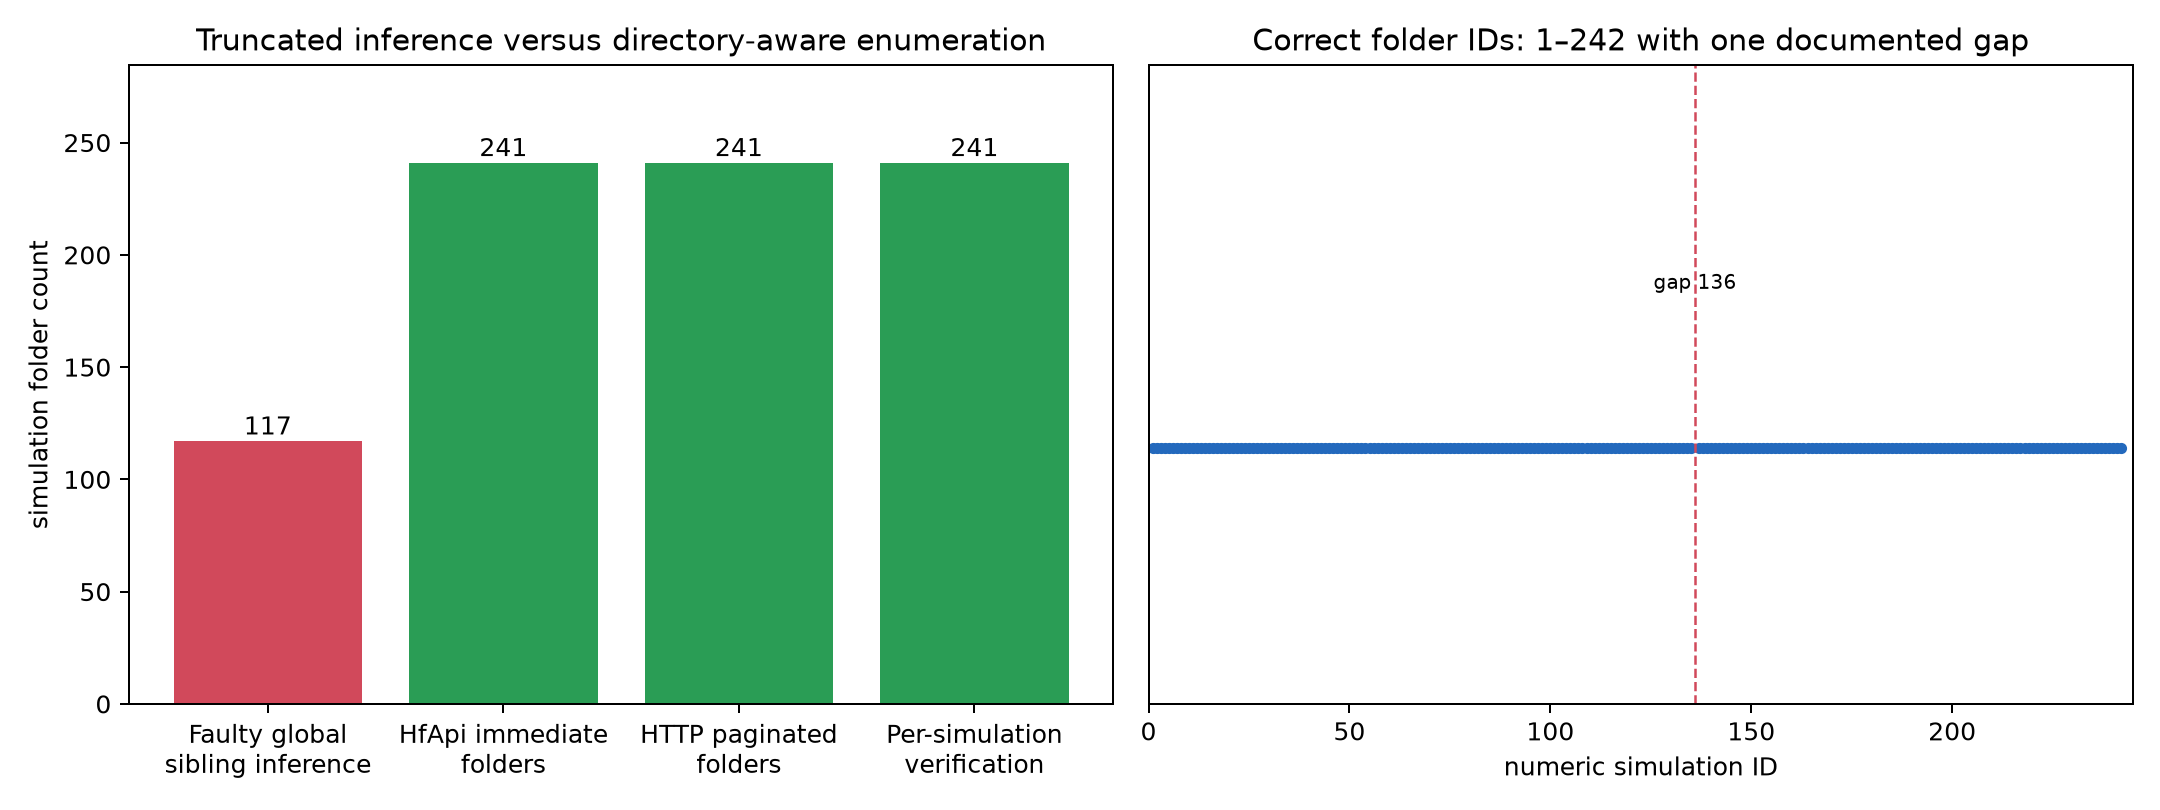

axis_center_motion.png


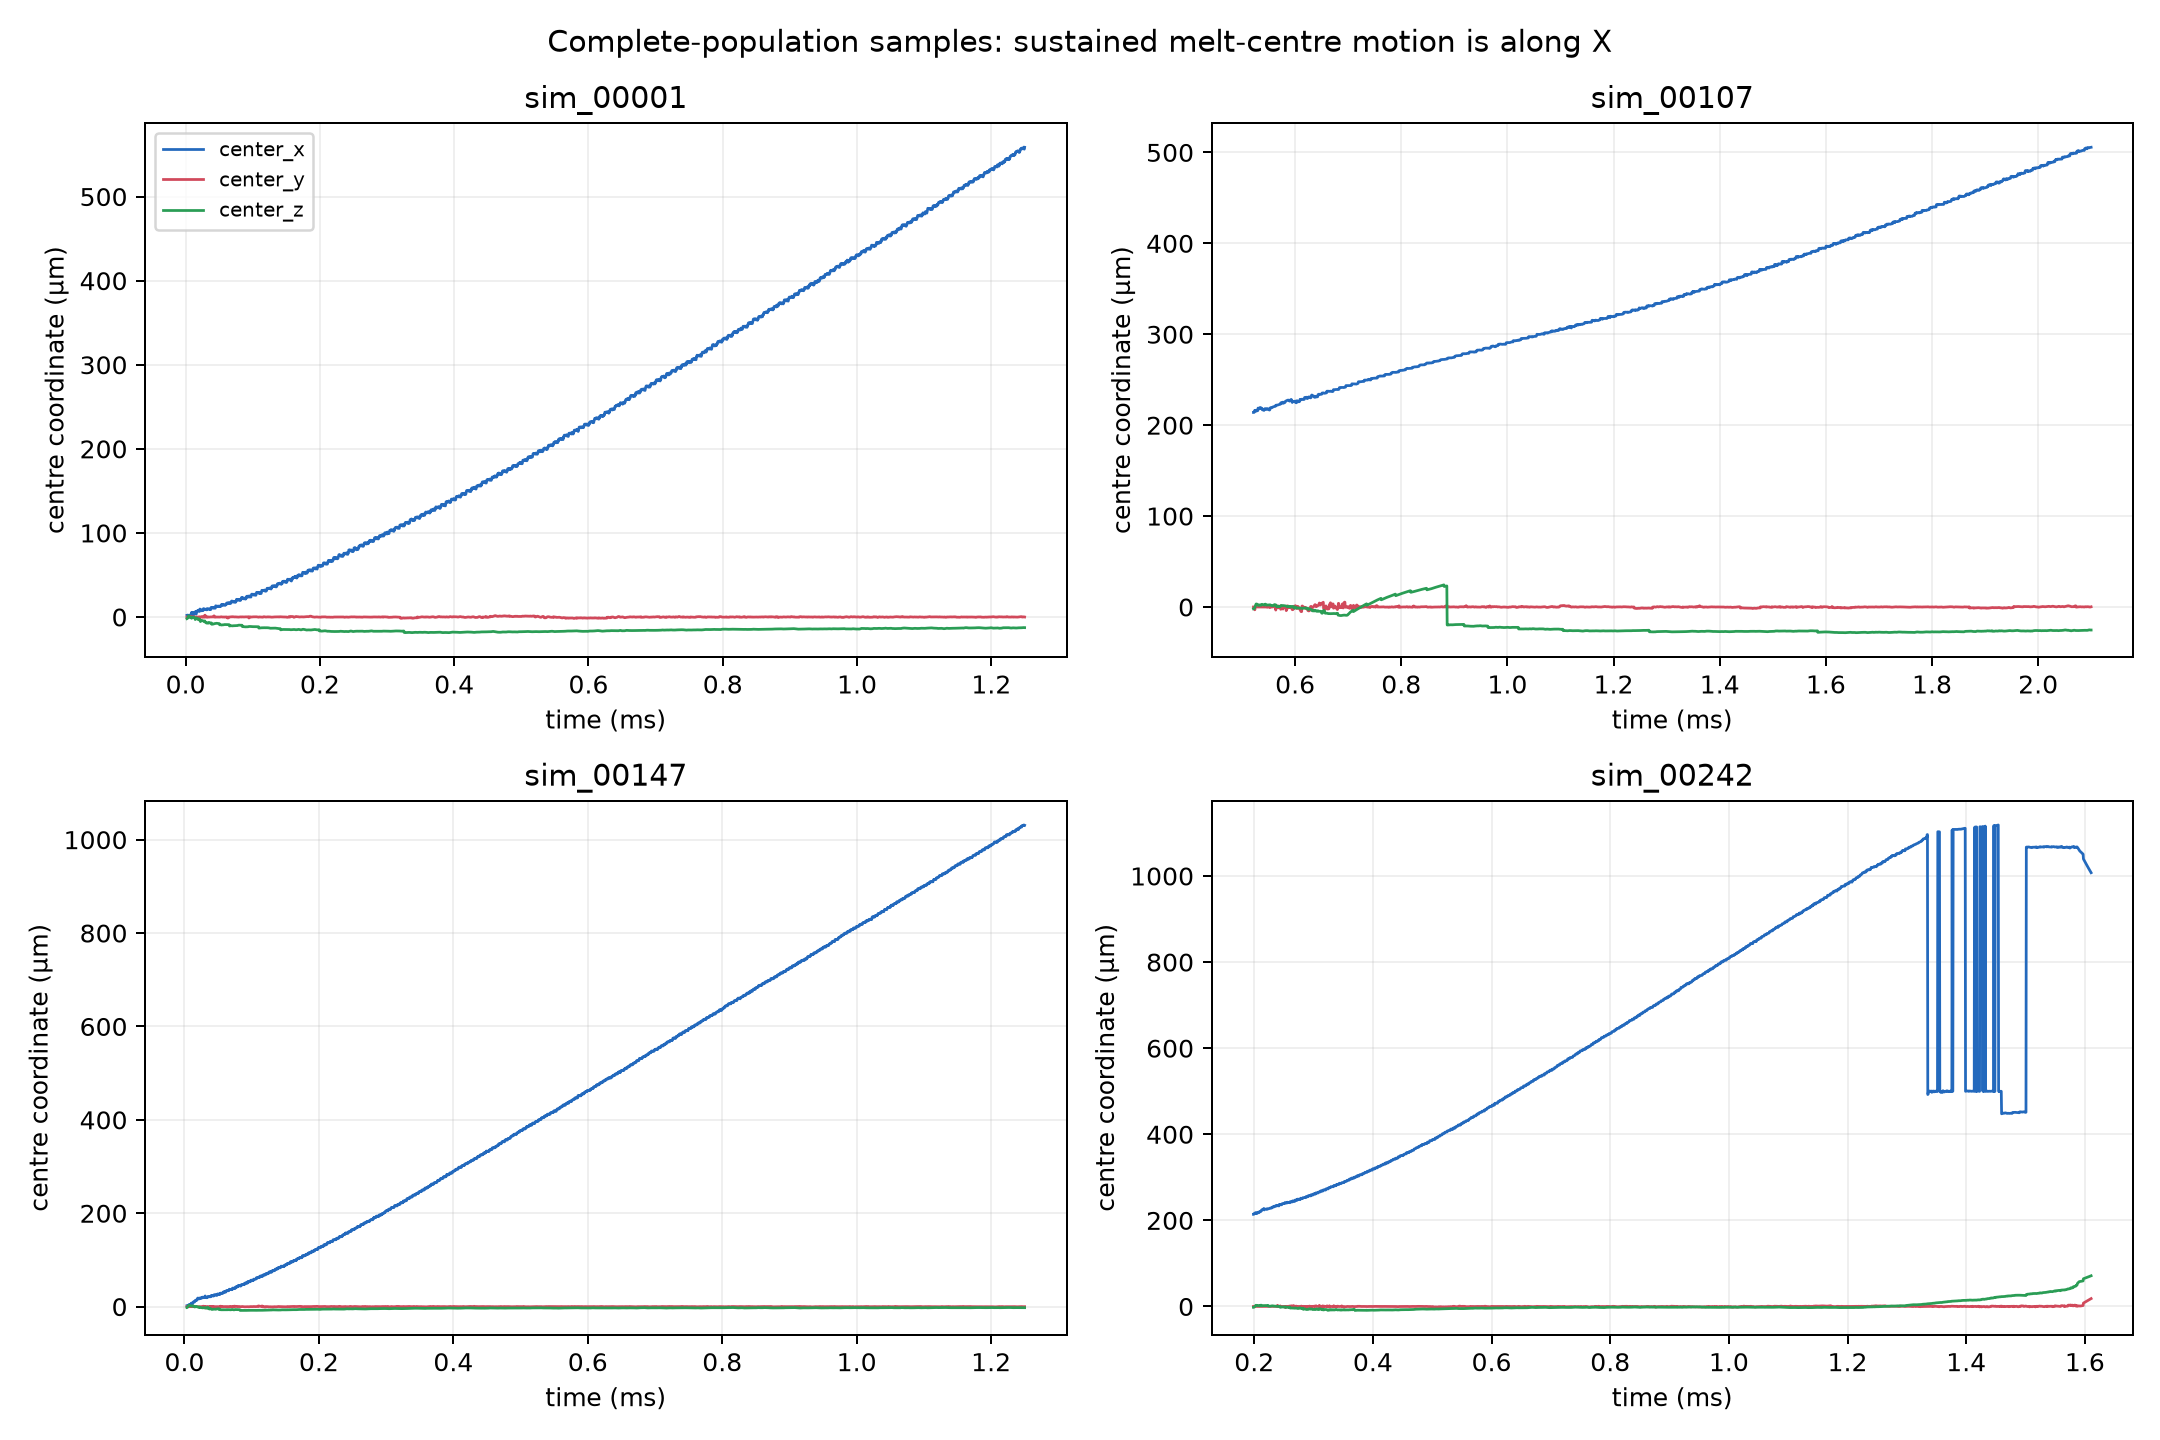

response_time_series_diagnostics.png


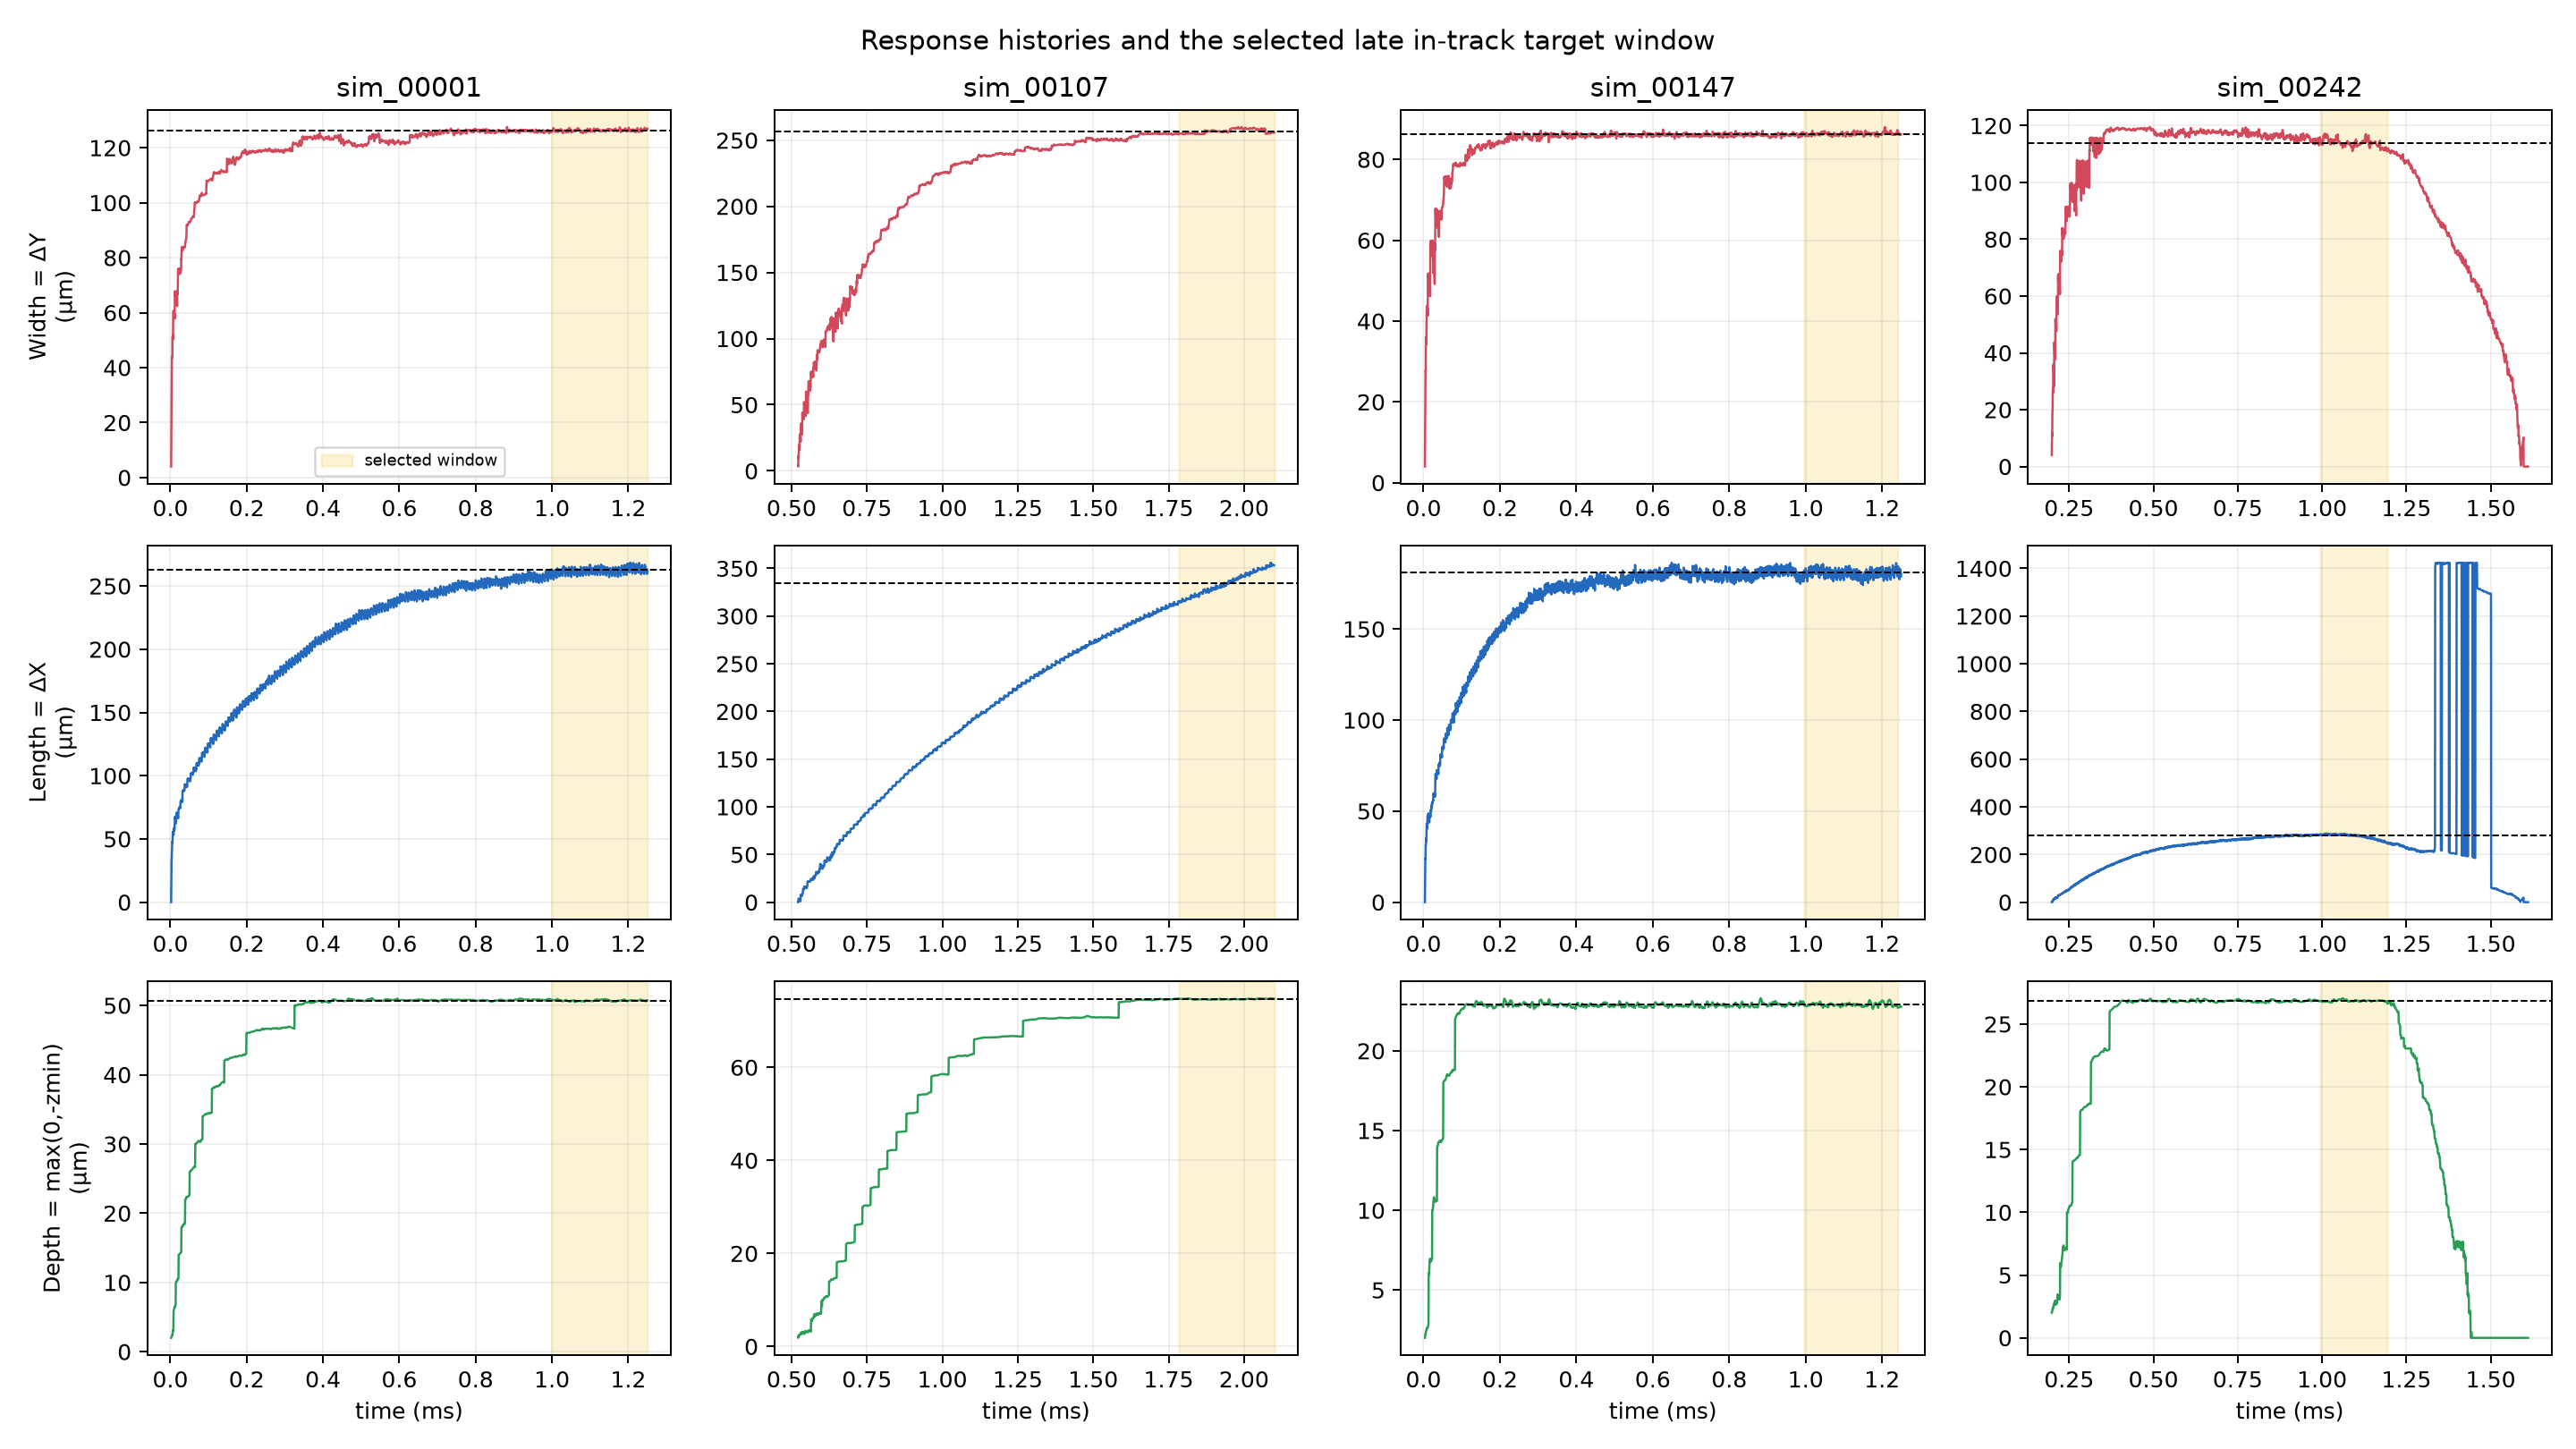

frame_axis_validation.png


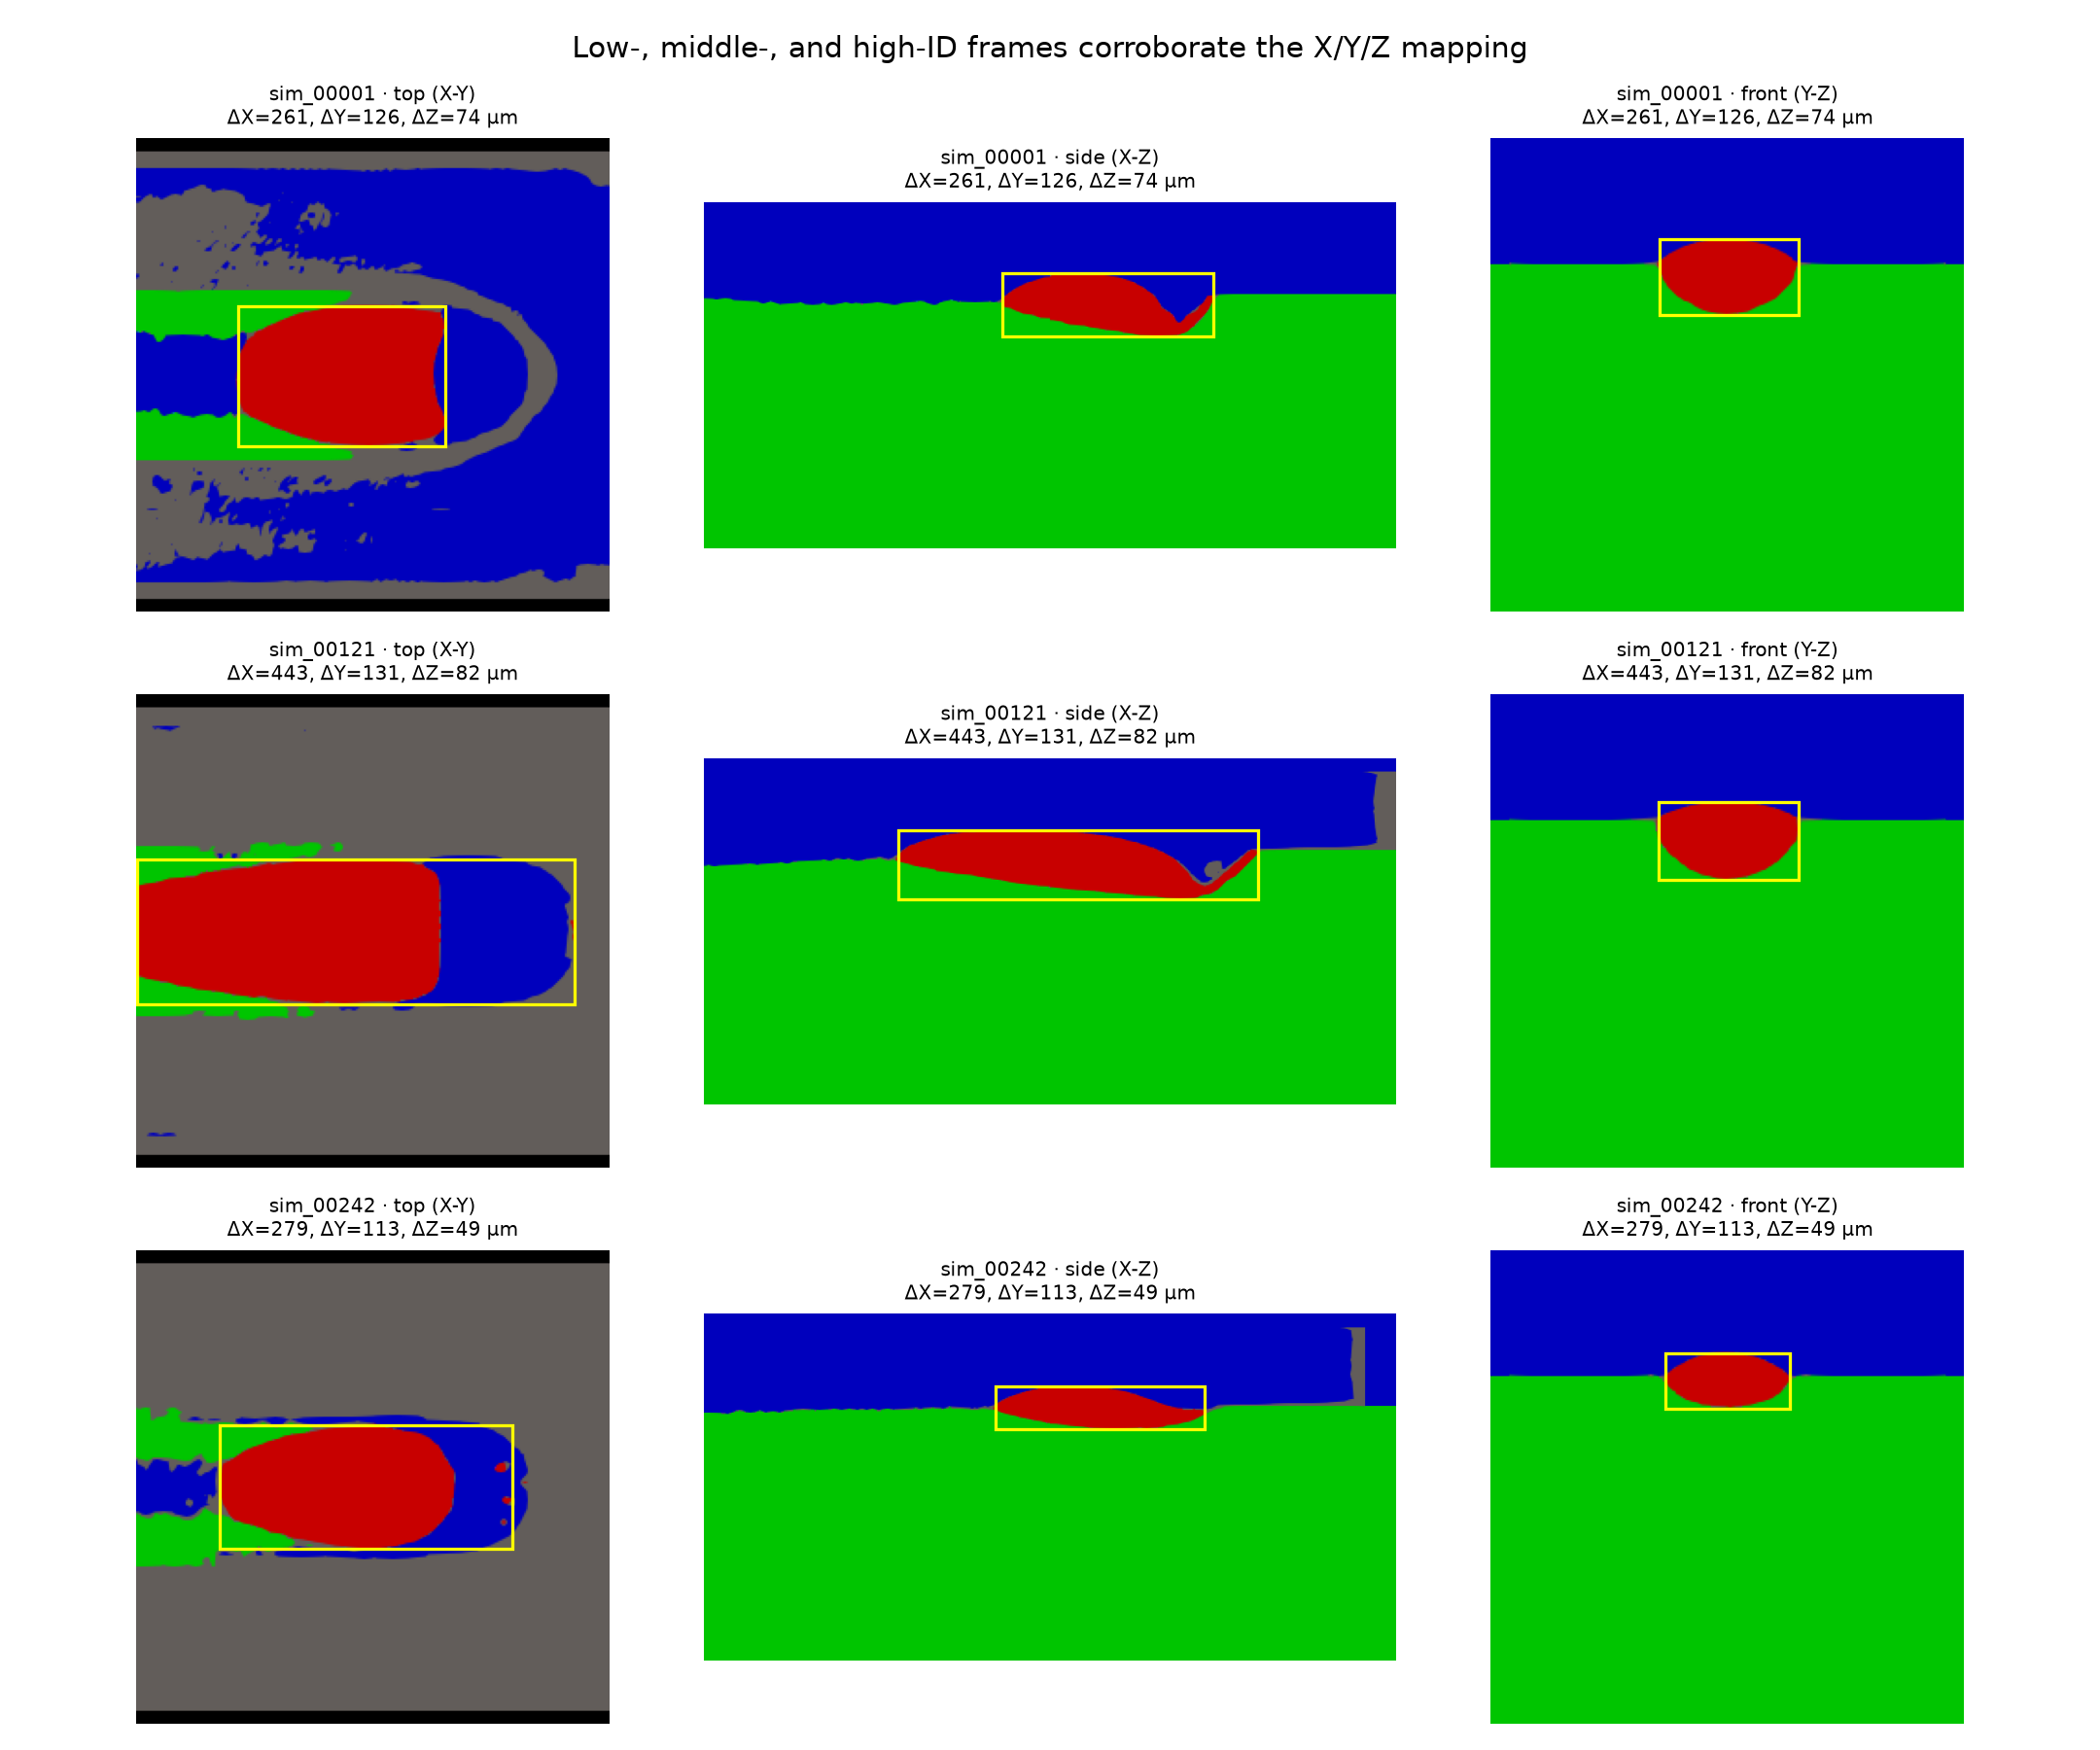

target_candidate_comparison.png


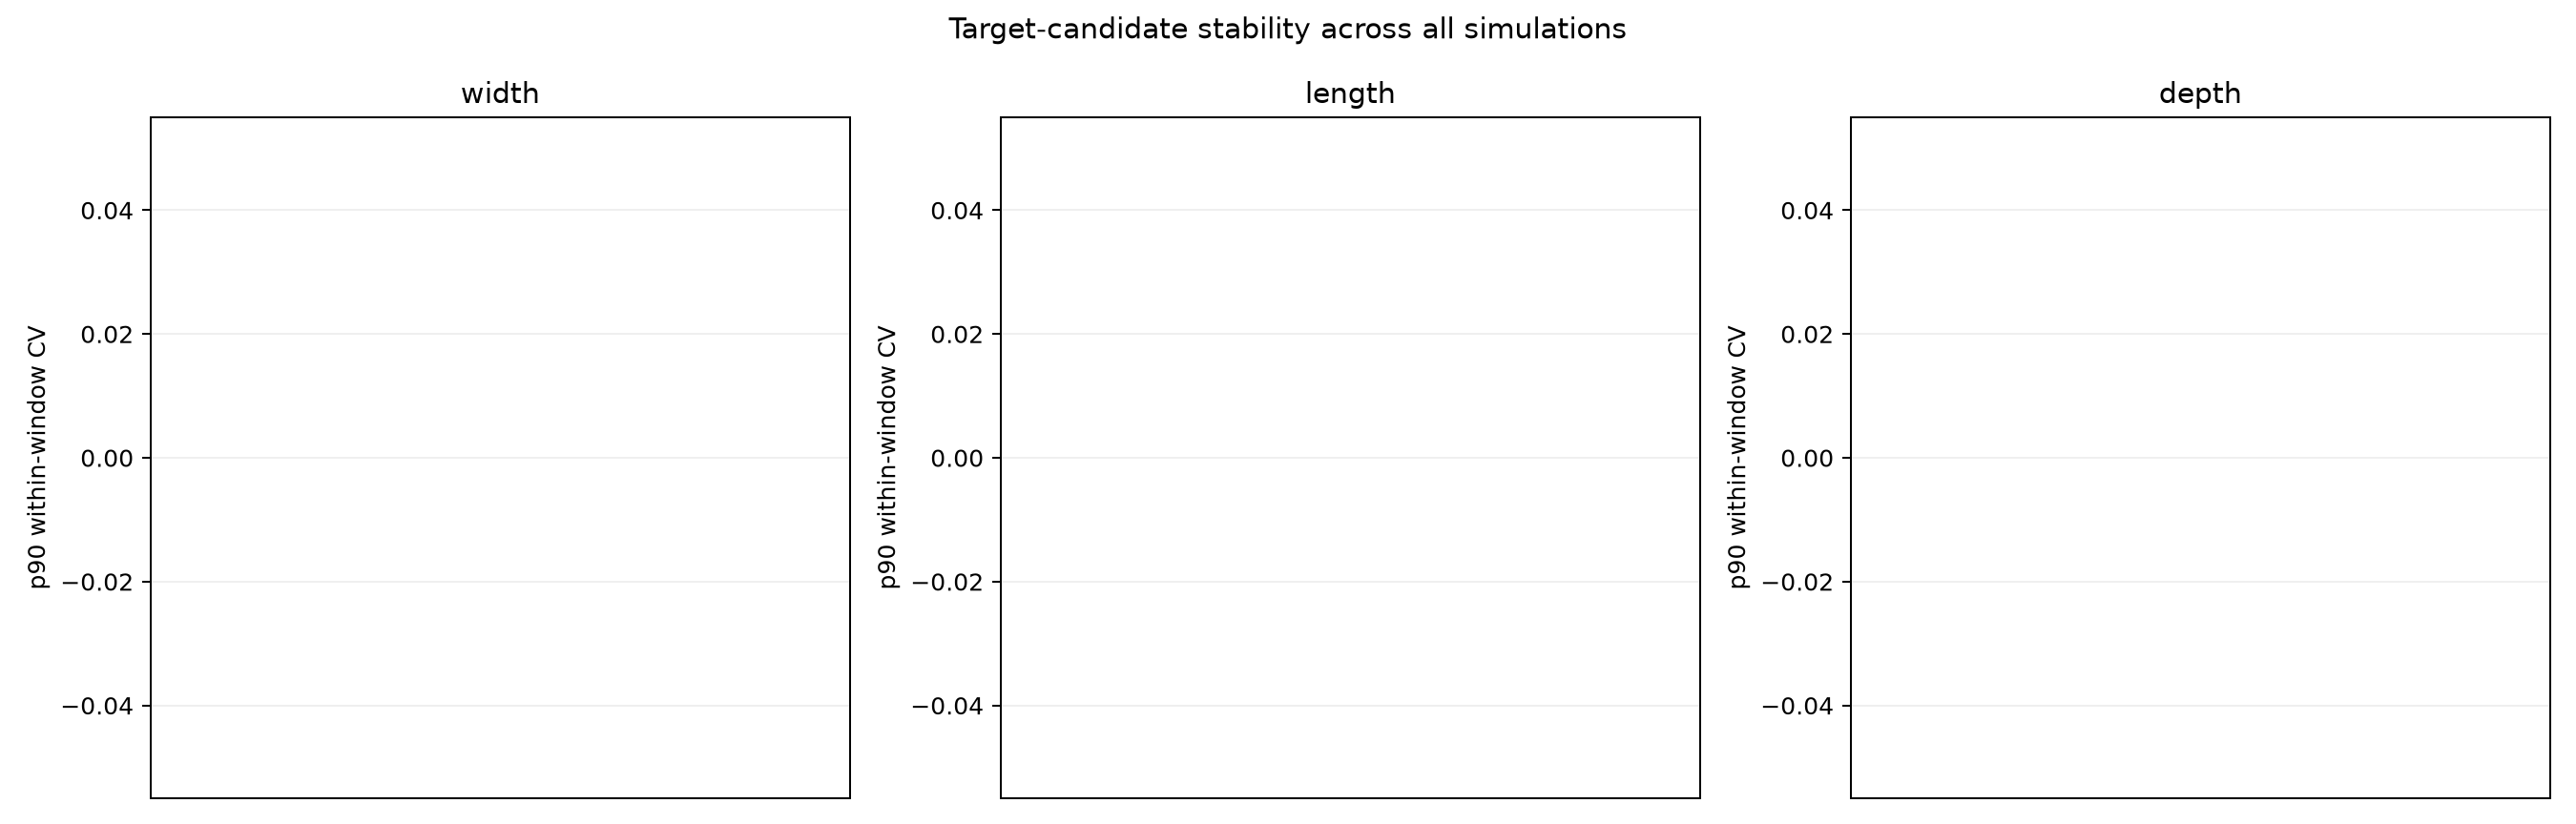

In [12]:
for filename in [
    "repository_enumeration_diagnostics.png",
    "axis_center_motion.png",
    "response_time_series_diagnostics.png",
    "frame_axis_validation.png",
    "target_candidate_comparison.png",
]:
    print(filename)
    display(Image(filename=str(OUT / filename)))

The figures provide complementary diagnostics: enumeration
completion, center motion, response time series, multi-view frame
evidence, and candidate stability. They are diagnostics, not
modelling results.

## 12. Anti-truncation and scientific validation

In [13]:
master = pd.read_csv(
    ROOT
    / "data"
    / "raw"
    / "huggingface"
    / "sph_dataset"
    / "final_data_processed"
    / "experiments.csv"
)
checks = pd.Series({
    "241 folders": len(folders) == 241,
    "sim_00242 present": "sim_00242" in set(folders["simulation_id"]),
    "only numeric gap is 136": gaps["missing_numeric_id"].tolist() == [136],
    "master/tree exact set match": (
        set(master["experiment_id"]) == set(folders["simulation_id"])
    ),
    "all monitor inventories complete": sim_files["monitor_dat_count"].eq(34).all(),
    "one response row per folder": (
        len(data) == len(folders)
        and data["simulation_id"].is_unique
    ),
    "all primary targets available": data[target_columns].notna().all().all(),
    "no incomplete simulation flags": (
        ~data["flag_incomplete_simulation"].astype(bool)
    ).all(),
})
display(checks)
assert checks.all()

241 folders                         True
sim_00242 present                   True
only numeric gap is 136             True
master/tree exact set match         True
all monitor inventories complete    True
one response row per folder         True
all primary targets available       True
no incomplete simulation flags      True
dtype: bool

## 13. Conclusions and Phase 1 readiness

All notebook-level assertions pass. The corrected Phase 1 table is
complete, population-wide, traceable to the immutable source
revision, and ready for later modelling. Phase 2 remains out of
scope.